In [2]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


dataset = pd.read_csv('/content/drive/MyDrive/Data_sets/Position_Salaries.csv')
dataset.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
display(dataset.describe())

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


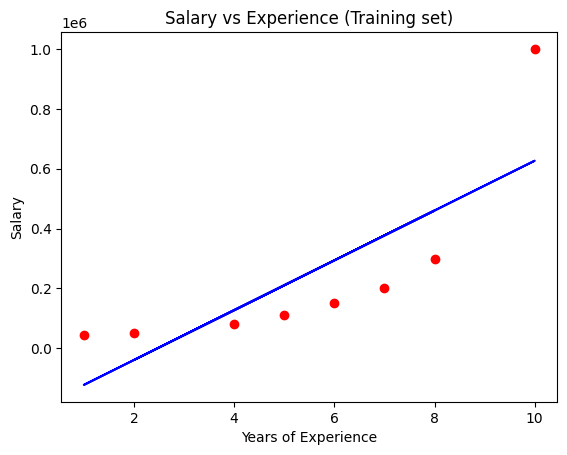

In [9]:
#simple linear regression for x=level and y=salary
x = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
#fit the train data
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train, y_train)
#show the fit plot
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color='red')
plt.plot(x_train, model.predict(x_train), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


In [10]:
# Training the Polynomial Regression model on the whole dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(x)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

print("✅ Models Trained Successfully!")


✅ Models Trained Successfully!


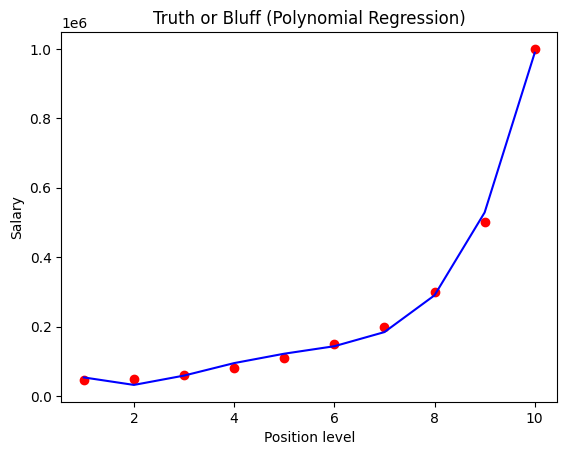

In [11]:
#show polynomial fit plot
plt.scatter(x, y, color = 'red')
plt.plot(x, lin_reg_2.predict(poly_reg.fit_transform(x)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [13]:
predicted_salary_linear = model.predict([[7]])
print(f"Predicted Salary (Linear Regression) for Level 7: {predicted_salary_linear[0]:.2f}")

Predicted Salary (Linear Regression) for Level 7: 377074.36


In [14]:
predicted_salary_polynomial = lin_reg_2.predict(poly_reg.transform([[7]]))
print(f"Predicted Salary (Polynomial Regression) for Level 7: {predicted_salary_polynomial[0]:.2f}")

Predicted Salary (Polynomial Regression) for Level 7: 184003.50


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Get predictions from the linear model on the full dataset
y_pred_linear = model.predict(x)

# Calculate metrics for Linear Regression
mse_linear = mean_squared_error(y, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

# Calculate Adjusted R-squared for Linear Regression
n = len(y) # number of samples
p = x.shape[1] # number of features (should be 1 for simple linear regression)
adjusted_r2_linear = 1 - (1 - r2_linear) * (n - 1) / (n - p - 1)

print("Linear Regression Metrics:")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"  R-squared (R2): {r2_linear:.4f}")
print(f"  Adjusted R-squared: {adjusted_r2_linear:.4f}")

Linear Regression Metrics:
  Mean Squared Error (MSE): 26748015364.52
  Root Mean Squared Error (RMSE): 163548.21
  Mean Absolute Error (MAE): 131794.52
  R-squared (R2): 0.6684
  Adjusted R-squared: 0.6269


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Get predictions from the polynomial model on the full dataset
y_pred_polynomial = lin_reg_2.predict(poly_reg.fit_transform(x))

# Calculate metrics for Polynomial Regression
mse_polynomial = mean_squared_error(y, y_pred_polynomial)
rmse_polynomial = np.sqrt(mse_polynomial)
mae_polynomial = mean_absolute_error(y, y_pred_polynomial)
r2_polynomial = r2_score(y, y_pred_polynomial)

# Calculate Adjusted R-squared for Polynomial Regression
n = len(y) # number of samples
p = X_poly.shape[1] - 1 # number of features (excluding the intercept term added by PolynomialFeatures)

# Ensure p is at least 1 for the formula to make sense, handle cases where n - p - 1 might be non-positive
if n - p - 1 <= 0:
    adjusted_r2_polynomial = float('nan') # Cannot compute adjusted R-squared if degrees of freedom are insufficient
else:
    adjusted_r2_polynomial = 1 - (1 - r2_polynomial) * (n - 1) / (n - p - 1)


print("Polynomial Regression Metrics:")
print(f"  Mean Squared Error (MSE): {mse_polynomial:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_polynomial:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_polynomial:.2f}")
print(f"  R-squared (R2): {r2_polynomial:.4f}")
print(f"  Adjusted R-squared: {adjusted_r2_polynomial:.4f}")

Polynomial Regression Metrics:
  Mean Squared Error (MSE): 210343822.84
  Root Mean Squared Error (RMSE): 14503.23
  Mean Absolute Error (MAE): 12681.82
  R-squared (R2): 0.9974
  Adjusted R-squared: 0.9953


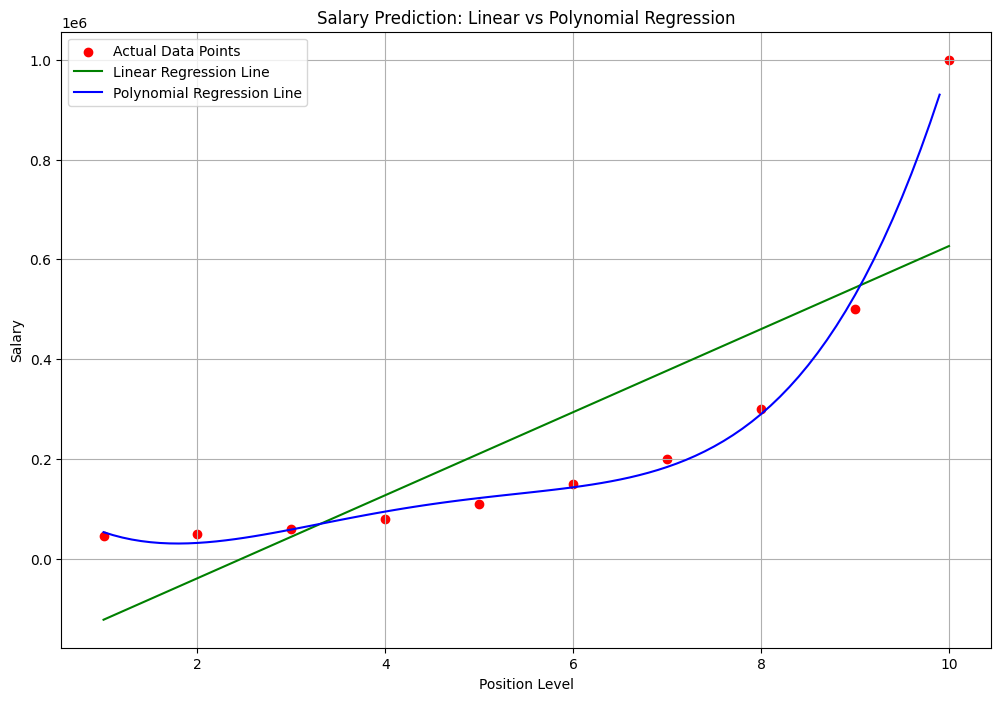

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot actual data points
plt.scatter(x, y, color = 'red', label = 'Actual Data Points')

# Plot Linear Regression line
plt.plot(x, model.predict(x), color = 'green', label = 'Linear Regression Line')

# Plot Polynomial Regression line
X_grid = np.arange(x.min(), x.max(), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue', label = 'Polynomial Regression Line')

plt.title('Salary Prediction: Linear vs Polynomial Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()